# Electricity Demand Forecasting Project - Complete Workflow

## Project Overview
This notebook builds a machine-learning model to forecast electricity demand using XGBoost.
It includes:
- Data loading and cleaning
- Feature engineering with proper handling of target leakage
- Train/validation/test split using chronological ordering
- Baseline models for comparison
- XGBoost model training
- Comprehensive evaluation and error analysis
- Model explainability

**IMPORTANT:** This dataset is **SYNTHETIC** (simulated). It represents typical residential electricity consumption patterns, similar to the real MORED dataset. Results should not be treated as real-world predictions without validation on actual data.

---

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Import ML libraries
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Import holidays
import holidays

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
data = pd.read_excel('data/electricity_demand_2025.xlsx')

print(f"Dataset loaded. Shape: {data.shape}")
print(f"\nFirst few rows:")
print(data.head())

Dataset loaded. Shape: (43848, 9)

First few rows:
            Timestamp  hour  dayofweek  month    year  dayofyear  Temperature  \
0 2020-01-01 00:00:00   0.0        2.0    1.0  2020.0        1.0         8.84   
1 2020-01-01 01:00:00   1.0        2.0    1.0  2020.0        1.0         7.29   
2 2020-01-01 02:00:00   2.0        2.0    1.0  2020.0        1.0         5.80   
3 2020-01-01 03:00:00   3.0        2.0    1.0  2020.0        1.0         7.89   
4 2020-01-01 04:00:00   4.0        2.0    1.0  2020.0        1.0         7.72   

   Humidity   Demand  
0     79.48  2407.56  
1     89.57  2300.65  
2     93.63  2664.95  
3     87.92  2516.60  
4       NaN  2601.76  


### 1.1 Initial Data Exploration

Let's examine the structure and content of the dataset:

In [3]:
# Display basic information
print("Dataset Info:")
print(data.info())
print(f"\nDate range:")
print(f"First timestamp: {data['Timestamp'].min()}")
print(f"Last timestamp: {data['Timestamp'].max()}")
print(f"Total observations: {len(data)}")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43844 non-null  datetime64[us]
 1   hour         43844 non-null  float64       
 2   dayofweek    43844 non-null  float64       
 3   month        43844 non-null  float64       
 4   year         43844 non-null  float64       
 5   dayofyear    43844 non-null  float64       
 6   Temperature  43187 non-null  float64       
 7   Humidity     43187 non-null  float64       
 8   Demand       43187 non-null  float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 3.0 MB
None

Date range:
First timestamp: 2020-01-01 00:00:00
Last timestamp: 2024-12-31 23:00:00
Total observations: 43848


In [4]:
# Display descriptive statistics
print("Descriptive Statistics:")
print(data[['Demand', 'Temperature', 'Humidity']].describe())

Descriptive Statistics:
             Demand   Temperature      Humidity
count  43187.000000  43187.000000  43187.000000
mean    2842.933068     17.482366     69.973692
std      489.076665      5.752818      9.891923
min     1646.280000      3.020000     39.180000
25%     2450.760000     13.240000     62.830000
50%     2782.810000     17.500000     70.010000
75%     3193.660000     21.740000     77.130000
max     4254.650000     31.920000     98.000000


---

## 2. Data Cleaning and Preparation

### 2.1 Handle Data Types and Set Index

In [5]:
# Convert Timestamp to datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Set Timestamp as index for time-series operations
data = data.set_index('Timestamp')

print(f"Index is now datetime: {data.index.dtype}")
print(f"Date range: {data.index.min()} to {data.index.max()}")

Index is now datetime: datetime64[us]
Date range: 2020-01-01 00:00:00 to 2024-12-31 23:00:00


### 2.2 Missing Data Analysis

Let's identify and understand missing values before handling them.

In [6]:
# Count missing values per column
print("Missing values per column:")
missing_counts = data.isnull().sum()
print(missing_counts)
print(f"\nTotal missing values: {data.isnull().sum().sum()}")
print(f"Percentage of missing data: {(data.isnull().sum().sum() / (len(data) * len(data.columns)) * 100):.2f}%")

# Show rows with any missing values
print(f"\nRows with missing values:")
rows_with_missing = data[data.isnull().any(axis=1)]
print(f"Count: {len(rows_with_missing)}")
if len(rows_with_missing) > 0:
    print(rows_with_missing.head(10))

Missing values per column:
hour             4
dayofweek        4
month            4
year             4
dayofyear        4
Temperature    661
Humidity       661
Demand         661
dtype: int64

Total missing values: 2003
Percentage of missing data: 0.57%

Rows with missing values:
Count: 1951
                     hour  dayofweek  month    year  dayofyear  Temperature  \
Timestamp                                                                     
2020-01-01 04:00:00   4.0        2.0    1.0  2020.0        1.0         7.72   
2020-01-04 07:00:00   7.0        5.0    1.0  2020.0        4.0          NaN   
2020-01-05 05:00:00   5.0        6.0    1.0  2020.0        5.0         9.31   
2020-01-05 15:00:00  15.0        6.0    1.0  2020.0        5.0        12.94   
2020-01-06 09:00:00   9.0        0.0    1.0  2020.0        6.0        10.94   
2020-01-06 21:00:00  21.0        0.0    1.0  2020.0        6.0        13.24   
2020-01-07 02:00:00   2.0        1.0    1.0  2020.0        7.0         6.71

### 2.3 Causal Missing Data Handling

Calendar features are recomputed from hourly timestamps. Weather uses forward fill, retaining initial unavailable values. Missing Demand targets remain missing and are excluded from training/evaluation. For lag and rolling history only, missing demand uses forward fill before shifting; no current or future demand enters a feature. Shared backend/features.py preserves hourly gaps and feature names.


In [7]:
from backend.features import add_engineered_features
data = add_engineered_features(data)
demand_missing_mask = data["Demand"].isna()
print(data.isna().sum())


After dropping completely empty rows: 43844 observations

Rows with missing Demand before interpolation: 657

Missing values after filling:
hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    0
Humidity       0
Demand         0
dtype: int64


### 2.4 Create Moroccan Holiday Feature

**Why holidays matter for electricity demand:**
- During holidays, demand patterns change dramatically (lower industrial use, different residential patterns)
- Restaurants, offices, and factories may operate on reduced schedules
- The model should learn different demand profiles for holidays vs. regular days

In [8]:
# Create binary holiday feature for Morocco
morocco_holidays = holidays.Morocco(years=data.index.year.unique())

# Check if each timestamp is a Moroccan holiday
data['is_holiday'] = data.index.map(lambda x: int(x.date() in morocco_holidays))

# Verify the feature
print(f"Holiday feature distribution:")
print(data['is_holiday'].value_counts())
print(f"\nPercentage of holidays: {data['is_holiday'].mean() * 100:.2f}%")

# Show some examples of holiday dates
print(f"\nExample holiday dates in the dataset:")
holiday_dates = data[data['is_holiday'] == 1].index.unique()[:5]
for date in holiday_dates:
    print(f"  {date.date()}: {morocco_holidays.get(date.date())}")

Holiday feature distribution:
is_holiday
0    41948
1     1896
Name: count, dtype: int64

Percentage of holidays: 4.32%

Example holiday dates in the dataset:
  2020-01-01: رأس السنة الميلادية
  2020-01-01: رأس السنة الميلادية
  2020-01-01: رأس السنة الميلادية
  2020-01-01: رأس السنة الميلادية
  2020-01-01: رأس السنة الميلادية


---

## 3. Feature Engineering

### 3.1 Add Time-Based Features

In [9]:
# Ensure calendar features are integers
data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']] = data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']].astype('int32')

# Add additional time-based features if not already present
if 'quarter' not in data.columns:
    data.insert(data.columns.get_loc('dayofyear') + 1, 'quarter', data.index.quarter.astype('int32'))

if 'weekofyear' not in data.columns:
    data.insert(data.columns.get_loc('quarter') + 1, 'weekofyear', data.index.isocalendar().week.astype('int32'))

if 'is_weekend' not in data.columns:
    data.insert(data.columns.get_loc('is_holiday') + 1, 'is_weekend', data.index.dayofweek.isin([5, 6]).astype('int32'))

print("Time-based features added:")
print(data[['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'quarter', 'weekofyear', 'is_weekend', 'is_holiday']].head(10))

Time-based features added:
                     hour  dayofweek  month  year  dayofyear  quarter  \
Timestamp                                                               
2020-01-01 00:00:00     0          2      1  2020          1        1   
2020-01-01 01:00:00     1          2      1  2020          1        1   
2020-01-01 02:00:00     2          2      1  2020          1        1   
2020-01-01 03:00:00     3          2      1  2020          1        1   
2020-01-01 04:00:00     4          2      1  2020          1        1   
2020-01-01 05:00:00     5          2      1  2020          1        1   
2020-01-01 06:00:00     6          2      1  2020          1        1   
2020-01-01 07:00:00     7          2      1  2020          1        1   
2020-01-01 08:00:00     8          2      1  2020          1        1   
2020-01-01 09:00:00     9          2      1  2020          1        1   

                     weekofyear  is_weekend  is_holiday  
Timestamp                             

### 3.2 Create Lag Features

**Lag features and why they work:**
- `Demand_lag_24hr`: Electricity demand from 24 hours ago. Highly predictive because daily demand patterns repeat.
- `demand_lag_168hr`: Demand from 168 hours (7 days) ago. Captures weekly seasonality.

These are available at forecast time (we know yesterday's demand), making them realistic for real-world prediction.

In [10]:
# Create lag features
data['Demand_lag_24hr'] = data['Demand'].ffill().shift(24)
data['demand_lag_168hr'] = data['Demand'].ffill().shift(168)  # 24 hours x 7 days = 168 hours

print("Lag features created:")
print(data[['Demand', 'Demand_lag_24hr', 'demand_lag_168hr']].head(180))

Lag features created:
                      Demand  Demand_lag_24hr  demand_lag_168hr
Timestamp                                                      
2020-01-01 00:00:00  2407.56              NaN               NaN
2020-01-01 01:00:00  2300.65              NaN               NaN
2020-01-01 02:00:00  2664.95              NaN               NaN
2020-01-01 03:00:00  2516.60              NaN               NaN
2020-01-01 04:00:00  2601.76              NaN               NaN
...                      ...              ...               ...
2020-01-08 07:00:00  3423.38          3325.33           3334.91
2020-01-08 08:00:00  3295.36          3168.75           3138.82
2020-01-08 09:00:00  3169.07          2926.30           3026.44
2020-01-08 10:00:00  2835.10          2966.45           2656.89
2020-01-08 11:00:00  2736.68          2636.63           2435.37

[180 rows x 3 columns]


### 3.3 Create Rolling Statistics (Without Target Leakage)

**Important: Avoiding Target Leakage**

Target leakage occurs when features include information about the value we're trying to predict. For example:
- ❌ WRONG: `data['Demand'].rolling(24).mean()` includes the current hour's demand in the 24-hour window
- ✅ CORRECT: `past_demand.rolling(24).mean()` where `past_demand = data['Demand'].ffill().shift(1)` only uses past observations

**Why this matters:**
- With target leakage, models show artificially perfect performance on training/test data
- In real deployment, the model will fail because future demand values aren't available
- Leakage masks real model weaknesses

In [11]:
# Create rolling statistics using only PAST demand values (no leakage)
past_demand = data['Demand'].ffill().shift(1)  # Shift by 1: only use values from the past

data['demand_rolling_mean_24hr'] = past_demand.rolling(window=24).mean()
data['demand_rolling_std_24hr'] = past_demand.rolling(window=24).std()

print("Rolling statistics created using only past demand values:")
print(data[['Demand', 'demand_rolling_mean_24hr', 'demand_rolling_std_24hr']].head(30))
print(f"\nNote: Rolling features have NaN values for the first 24 rows (insufficient history)")

Rolling statistics created using only past demand values:
                      Demand  demand_rolling_mean_24hr  \
Timestamp                                                
2020-01-01 00:00:00  2407.56                       NaN   
2020-01-01 01:00:00  2300.65                       NaN   
2020-01-01 02:00:00  2664.95                       NaN   
2020-01-01 03:00:00  2516.60                       NaN   
2020-01-01 04:00:00  2601.76                       NaN   
2020-01-01 05:00:00  2874.23                       NaN   
2020-01-01 06:00:00  3005.75                       NaN   
2020-01-01 07:00:00  3334.91                       NaN   
2020-01-01 08:00:00  3138.82                       NaN   
2020-01-01 09:00:00  3026.44                       NaN   
2020-01-01 10:00:00  2656.89                       NaN   
2020-01-01 11:00:00  2435.37                       NaN   
2020-01-01 12:00:00  2312.09                       NaN   
2020-01-01 13:00:00  2280.38                       NaN   
2020-01-01 14:

### 3.4 Drop Rows with Missing Values

**Why drop incomplete rows now?**
- We created lag features that shift data by up to 168 hours
- We created rolling features that need 24 prior observations
- Rows with NaN values in these features cannot be used for training or evaluation
- It's better to drop them now than to leak information through imputation

In [12]:
from backend.features import add_engineered_features
data = add_engineered_features(data).dropna()
print(f"Complete causal feature rows: {len(data)}")


Missing values before dropping incomplete rows:
hour                          0
dayofweek                     0
month                         0
year                          0
dayofyear                     0
quarter                       0
weekofyear                    0
Temperature                   0
Humidity                      0
Demand                        0
is_holiday                    0
is_weekend                    0
Demand_lag_24hr              24
demand_lag_168hr            168
demand_rolling_mean_24hr     24
demand_rolling_std_24hr      24
dtype: int64

Dataset shape before dropping NaN: (43844, 16)
Dataset shape after dropping NaN: (43676, 16)
Rows removed: 0 (due to lag features requiring history)

Missing values after cleaning: 0


### 3.5 Feature Documentation Table

Here's a complete reference of all features used in the model:

In [13]:
# Create feature documentation
feature_docs = pd.DataFrame({
    'Feature Name': [
        'hour',
        'dayofweek',
        'month',
        'year',
        'dayofyear',
        'quarter',
        'weekofyear',
        'is_weekend',
        'is_holiday',
        'Temperature',
        'Humidity',
        'Demand_lag_24hr',
        'demand_lag_168hr',
        'demand_rolling_mean_24hr',
        'demand_rolling_std_24hr'
    ],
    'Meaning': [
        'Hour of day (0-23)',
        'Day of week (0=Monday, 6=Sunday)',
        'Month (1-12)',
        'Year',
        'Day of year (1-366)',
        'Quarter (1-4)',
        'ISO week number (1-53)',
        'Binary: 1 if Saturday/Sunday, 0 otherwise',
        'Binary: 1 if Moroccan holiday, 0 otherwise',
        'Temperature (°C)',
        'Humidity (%)',
        'Demand from 24 hours ago (MW)',
        'Demand from 168 hours ago (MW)',
        'Average demand from past 24 hours (MW)',
        'Standard deviation of past 24 hours demand (MW)'
    ],
    'Why Predictive': [
        'Demand varies significantly by hour of day',
        'Weekday vs weekend patterns differ',
        'Seasonal variation (heating/cooling)',
        'Long-term trends',
        'Seasonal patterns throughout year',
        'Quarterly business/seasonal effects',
        'Weekly business cycles',
        'Weekends have different usage patterns',
        'Holidays affect industrial/commercial load',
        'Temperature drives HVAC load (heating/cooling)',
        'Humidity affects comfort (AC usage)',
        'Daily patterns repeat reliably',
        'Weekly patterns repeat reliably',
        'Recent average indicates trend',
        'Variability indicates demand volatility'
    ],
    'Available at Forecast Time': [
        'Yes (from calendar)',
        'Yes (from calendar)',
        'Yes (from calendar)',
        'Yes (from calendar)',
        'Yes (from calendar)',
        'Yes (from calendar)',
        'Yes (from calendar)',
        'Yes (from calendar)',
        'Yes (from calendar)',
        'Only with forecast (weather prediction)',
        'Only with forecast (weather prediction)',
        'Yes (historical data)',
        'Yes (historical data)',
        'Yes (historical data)',
        'Yes (historical data)'
    ]
})

print(feature_docs.to_string(index=False))

            Feature Name                                         Meaning                                 Why Predictive              Available at Forecast Time
                    hour                              Hour of day (0-23)     Demand varies significantly by hour of day                     Yes (from calendar)
               dayofweek                Day of week (0=Monday, 6=Sunday)             Weekday vs weekend patterns differ                     Yes (from calendar)
                   month                                    Month (1-12)           Seasonal variation (heating/cooling)                     Yes (from calendar)
                    year                                            Year                               Long-term trends                     Yes (from calendar)
               dayofyear                             Day of year (1-366)              Seasonal patterns throughout year                     Yes (from calendar)
                 quarter                

---

## 4. Exploratory Data Analysis

### 4.1 Raw Demand Over Time

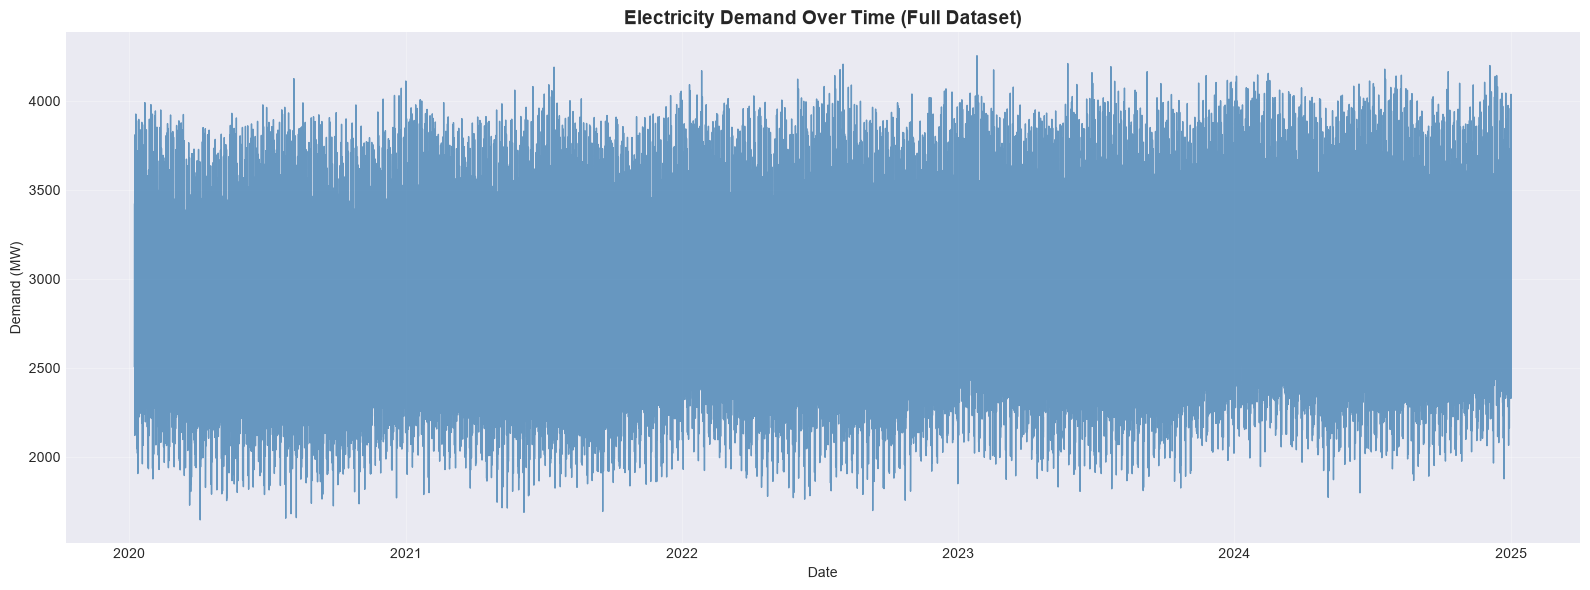


Demand Statistics:
  Minimum: 1646.28 MW
  Maximum: 4254.65 MW
  Mean: 2842.92 MW
  Std Dev: 488.06 MW


In [14]:
# Plot electricity demand over the entire time period
plt.figure(figsize=(16, 6))
plt.plot(data.index, data['Demand'], color='steelblue', linewidth=1, alpha=0.8)
plt.title('Electricity Demand Over Time (Full Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDemand Statistics:")
print(f"  Minimum: {data['Demand'].min():.2f} MW")
print(f"  Maximum: {data['Demand'].max():.2f} MW")
print(f"  Mean: {data['Demand'].mean():.2f} MW")
print(f"  Std Dev: {data['Demand'].std():.2f} MW")

### 4.2 Demand by Hour of Day

Electricity demand typically peaks during morning (breakfast) and evening (dinner/TV) hours.

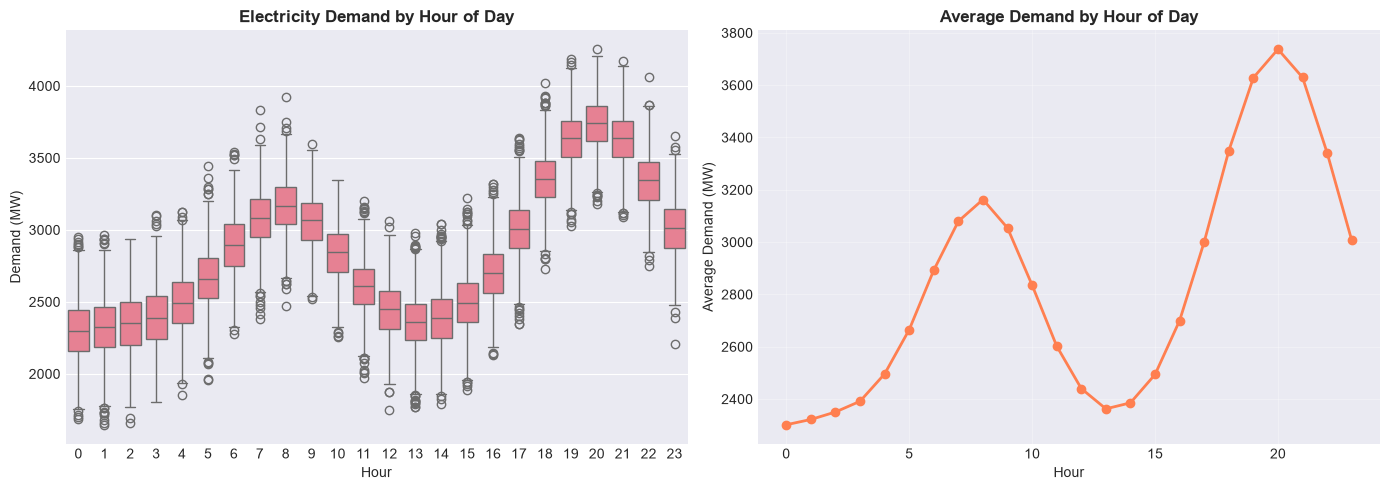

Peak demand hours:
  Hour 20: 3737.40 MW
  Hour 21: 3629.53 MW
  Hour 19: 3628.69 MW
  Hour 18: 3349.23 MW
  Hour 22: 3341.24 MW


In [15]:
# Analyze demand patterns by hour
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=data, x='hour', y='Demand', ax=axes[0])
axes[0].set_title('Electricity Demand by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Demand (MW)')

# Line plot of hourly average
hourly_avg = data.groupby('hour')['Demand'].mean()
axes[1].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, markersize=6, color='coral')
axes[1].set_title('Average Demand by Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average Demand (MW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Peak demand hours:")
peak_hours = hourly_avg.nlargest(5)
for hour, demand in peak_hours.items():
    print(f"  Hour {hour:2d}: {demand:.2f} MW")

### 4.3 Demand by Month (Seasonality)

Demand varies seasonally due to heating (winter) and cooling (summer) needs.

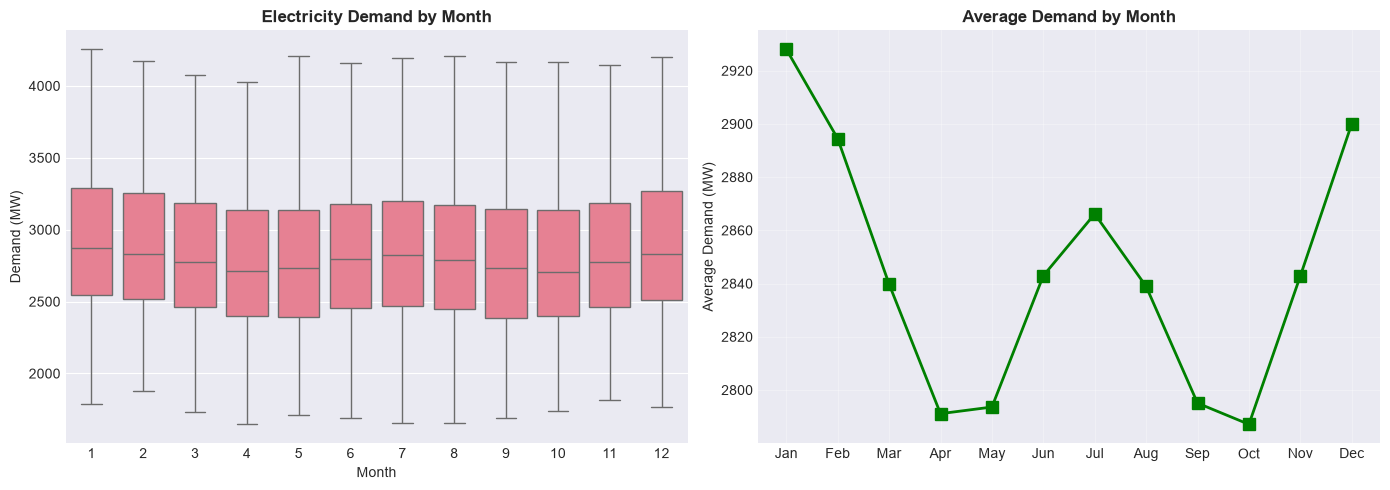

In [16]:
# Analyze seasonal patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=data, x='month', y='Demand', ax=axes[0])
axes[0].set_title('Electricity Demand by Month', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Demand (MW)')

# Line plot of monthly average
monthly_avg = data.groupby('month')['Demand'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1].plot(monthly_avg.index, monthly_avg.values, marker='s', linewidth=2, markersize=8, color='green')
axes[1].set_title('Average Demand by Month', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_ylabel('Average Demand (MW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4 Weekday vs Weekend

Weekends typically have different consumption patterns (more residential, less commercial/industrial).

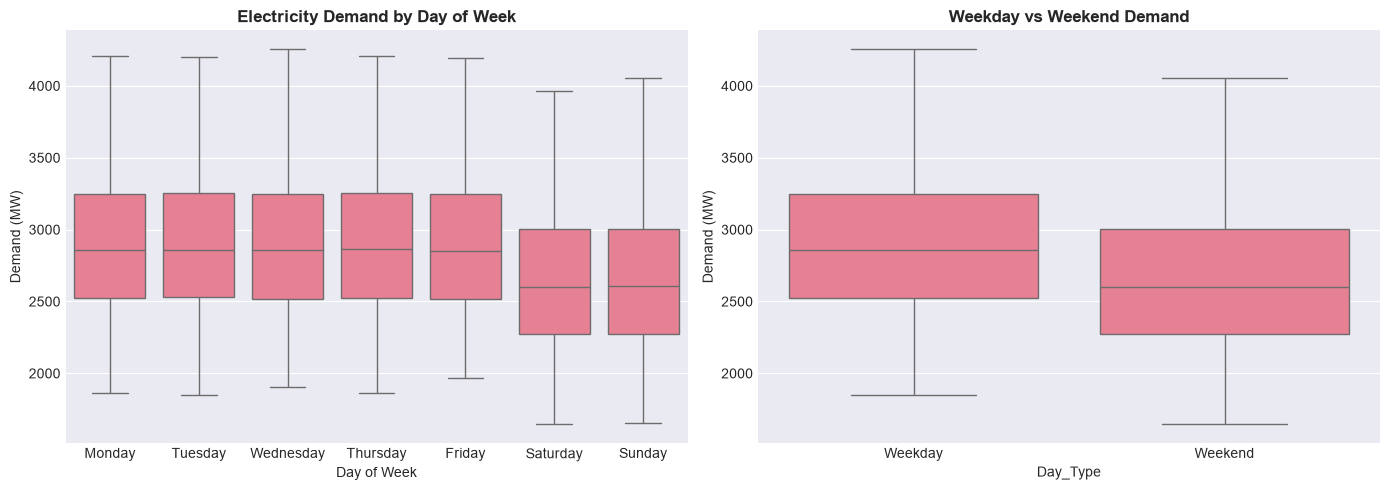

Average demand - Weekday: 2914.01 MW
Average demand - Weekend: 2665.21 MW
Difference: 248.79 MW (8.5%)


In [17]:
# Compare weekday vs weekend demand
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create day of week labels
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Box plot by day of week
sns.boxplot(data=data, x='dayofweek', y='Demand', ax=axes[0])
axes[0].set_title('Electricity Demand by Day of Week', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(day_names)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Demand (MW)')

# Compare weekend vs weekday
data_temp = data.copy()
data_temp['Day_Type'] = data_temp['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
sns.boxplot(data=data_temp, x='Day_Type', y='Demand', ax=axes[1])
axes[1].set_title('Weekday vs Weekend Demand', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Demand (MW)')

plt.tight_layout()
plt.show()

weekday_avg = data[data['is_weekend'] == 0]['Demand'].mean()
weekend_avg = data[data['is_weekend'] == 1]['Demand'].mean()
print(f"Average demand - Weekday: {weekday_avg:.2f} MW")
print(f"Average demand - Weekend: {weekend_avg:.2f} MW")
print(f"Difference: {abs(weekday_avg - weekend_avg):.2f} MW ({abs(weekday_avg - weekend_avg) / weekday_avg * 100:.1f}%)")

### 4.5 Demand vs Temperature

Temperature affects demand significantly through HVAC loads (heating and cooling).

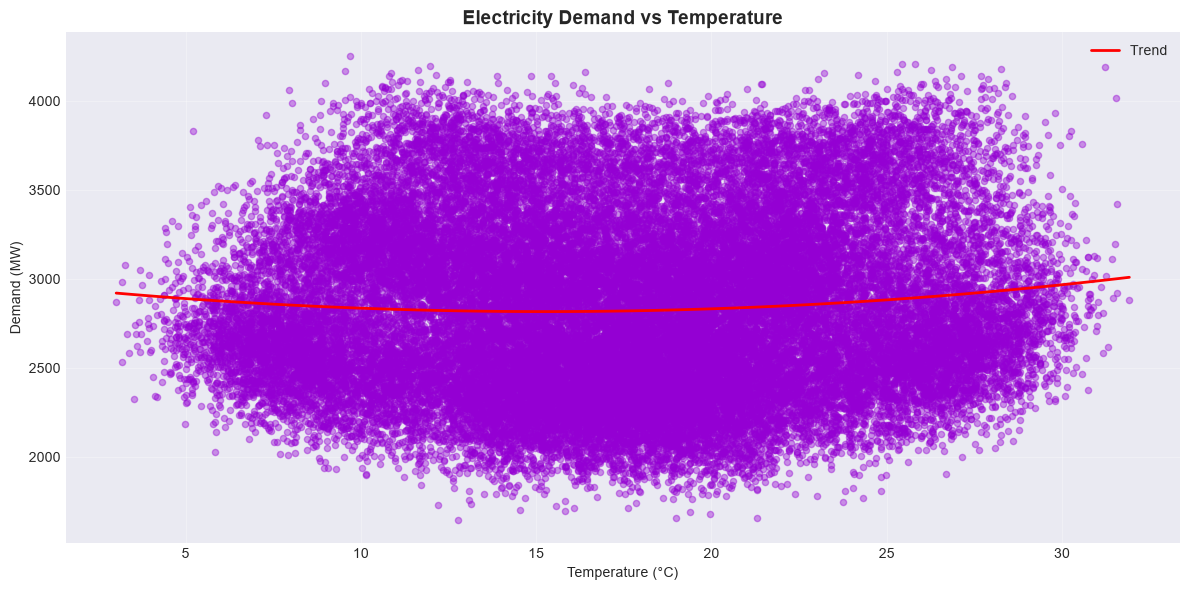

Correlation between Temperature and Demand: 0.037


In [18]:
# Plot demand vs temperature
plt.figure(figsize=(12, 6))
plt.scatter(data['Temperature'], data['Demand'], alpha=0.4, s=20, color='darkviolet')
plt.title('Electricity Demand vs Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Demand (MW)')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(data['Temperature'], data['Demand'], 2)
p = np.poly1d(z)
temp_range = np.linspace(data['Temperature'].min(), data['Temperature'].max(), 100)
plt.plot(temp_range, p(temp_range), 'r-', linewidth=2, label='Trend')
plt.legend()
plt.tight_layout()
plt.show()

correlation = data['Temperature'].corr(data['Demand'])
print(f"Correlation between Temperature and Demand: {correlation:.3f}")

### 4.6 Feature Correlation Matrix

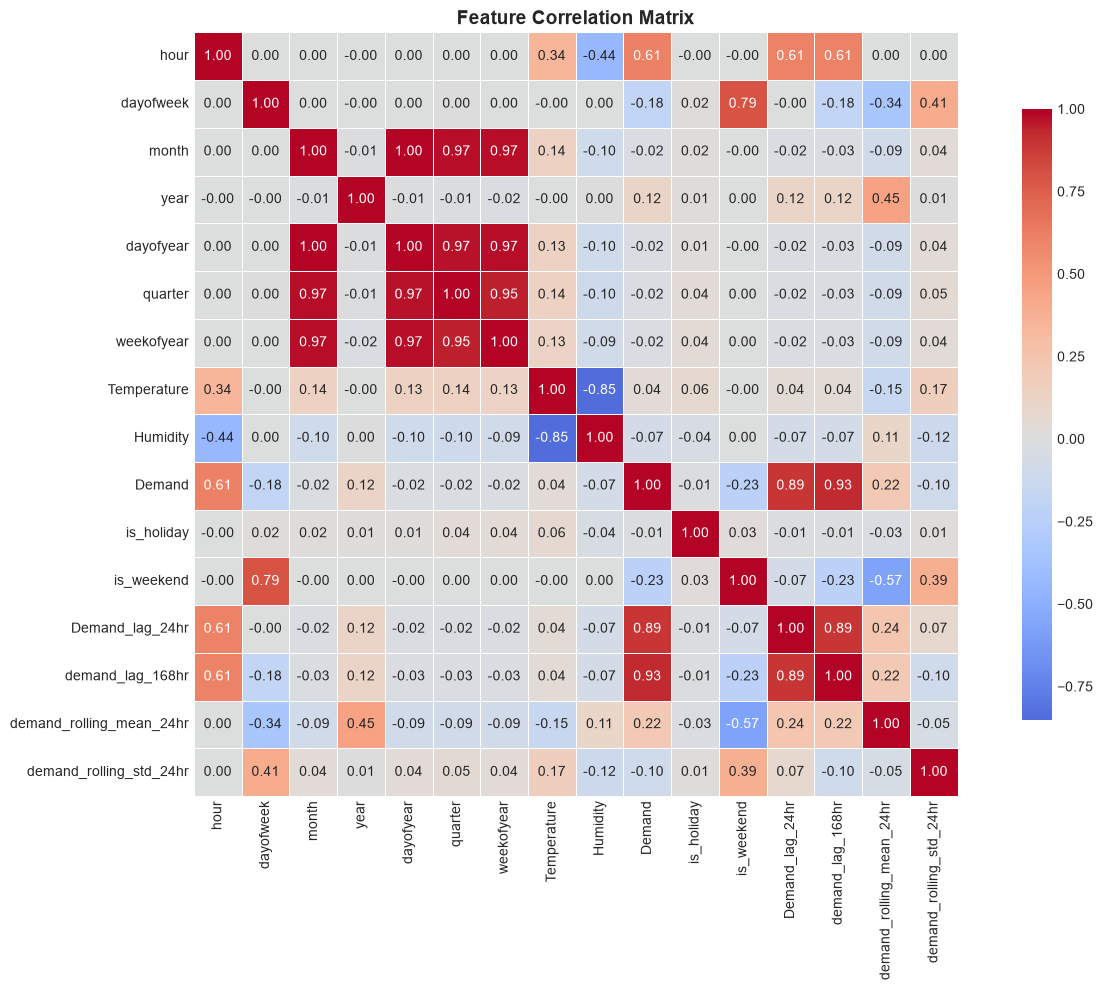


Correlation with Demand (sorted by absolute value):
Demand                      1.000000
demand_lag_168hr            0.927211
Demand_lag_24hr             0.894602
hour                        0.609653
is_weekend                  0.230293
demand_rolling_mean_24hr    0.218999
dayofweek                   0.182221
year                        0.116375
demand_rolling_std_24hr     0.099080
Humidity                    0.073795
Temperature                 0.036625
quarter                     0.023480
weekofyear                  0.022786
month                       0.022387
dayofyear                   0.022130
is_holiday                  0.006311
Name: Demand, dtype: float64


In [19]:
# Create correlation matrix
correlation_matrix = data.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlations with Demand
print("\nCorrelation with Demand (sorted by absolute value):")
demand_corr = correlation_matrix['Demand'].abs().sort_values(ascending=False)
print(demand_corr)

---

## 5. Data Splitting Strategy

### Why Chronological Splitting Matters

**Important Principle:** Time-series data must NEVER be randomly shuffled for train/test splitting.

**Reasons:**
1. **Temporal Dependence**: Electricity demand today depends on yesterday. Random shuffling breaks this relationship.
2. **Real-World Scenarios**: In production, we always predict the future using only past data. We can't access future information.
3. **Overfitting Hidden**: Random splitting allows information from the future to leak into training, creating unrealistically high performance.

**Our Splitting Strategy:**
- **Training Set**: All data before 2024-01-01
- **Validation Set**: 2024-01-01 onwards (for early stopping and model tuning)
- **Purpose**: The validation set helps with early stopping WITHOUT using a separate test set during training

This ensures the model only learns from past data and is evaluated fairly on unseen future observations.

In [20]:
# Prepare features and target
X = data.drop('Demand', axis=1)
y = data['Demand']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (43676, 15)
Target shape: (43676,)

Feature columns: ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'quarter', 'weekofyear', 'Temperature', 'Humidity', 'is_holiday', 'is_weekend', 'Demand_lag_24hr', 'demand_lag_168hr', 'demand_rolling_mean_24hr', 'demand_rolling_std_24hr']


In [21]:
# Split data chronologically into THREE sets (fixes a real methodological gap):
# - Training:       up to 2022-12-31
# - Early-stopping: 2023 (used ONLY inside model.fit()'s eval_set, to decide
#                   when to stop adding trees -- never used for reported metrics)
# - Held-out test:  2024 onwards (used ONLY for final reported metrics and every
#                   evaluation/plot below -- the model never sees this data in
#                   any way during training)
#
# Previously this project reused the same 2024+ set for both early stopping and
# final metrics, which makes reported scores slightly optimistic (the model's
# training was indirectly tuned against the set it was then "tested" on). This
# split removes that overlap.

X_train = X.loc[:'2022-12-31']
y_train = y.loc[:'2022-12-31']

X_earlystop = X.loc['2023-01-01':'2023-12-31']
y_earlystop = y.loc['2023-01-01':'2023-12-31']

# Named X_val/y_val for compatibility with the rest of this notebook, but this
# is the TRUE held-out test set: never used in training or early stopping.
X_val = X.loc['2024-01-01':]
y_val = y.loc['2024-01-01':]

print("Training Set:")
print(f"  Shape: {X_train.shape}")
print(f"  Date range: {X_train.index.min()} to {X_train.index.max()}")
print(f"  Observations: {len(X_train)}")

print("\nEarly-Stopping Set (decides when to stop training only):")
print(f"  Shape: {X_earlystop.shape}")
print(f"  Date range: {X_earlystop.index.min()} to {X_earlystop.index.max()}")
print(f"  Observations: {len(X_earlystop)}")

print("\nHeld-Out Test Set (final metrics only, never seen during training):")
print(f"  Shape: {X_val.shape}")
print(f"  Date range: {X_val.index.min()} to {X_val.index.max()}")
print(f"  Observations: {len(X_val)}")

print(f"\nTotal: {len(X_train) + len(X_earlystop) + len(X_val)} observations")


Training Set:
  Shape: (26132, 15)
  Date range: 2020-01-08 00:00:00 to 2022-12-31 23:00:00
  Observations: 26132

Early-Stopping Set (decides when to stop training only):
  Shape: (8760, 15)
  Date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00
  Observations: 8760

Held-Out Test Set (final metrics only, never seen during training):
  Shape: (8784, 15)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Observations: 8784

Total: 43676 observations


---

## 6. Baseline Models

### Why Baselines Matter

A machine-learning model is only valuable if it outperforms simple baselines. Baselines:
- Show what performance is achievable without ML
- Identify if the ML model actually adds value
- Provide a sanity check (if ML does worse than baseline, something is wrong)

**Our Baselines:**
1. **24-Hour Naive**: Predict using demand from 24 hours ago (typical daily pattern repeats)
2. **168-Hour Naive**: Predict using demand from 7 days ago (weekly pattern repeats)

In [22]:
# Baseline 1: Predict using 24-hour lag (yesterday's demand)
baseline_24hr = data.loc[y_val.index, 'Demand_lag_24hr'].dropna()
y_val_aligned = y_val.loc[baseline_24hr.index]

print("Baseline 1: 24-Hour Naive Forecast")
print(f"  Prediction method: Use demand from 24 hours ago")
print(f"  Rationale: Electricity demand typically follows daily patterns that repeat")
print(f"  Predictions shape: {baseline_24hr.shape}")

Baseline 1: 24-Hour Naive Forecast
  Prediction method: Use demand from 24 hours ago
  Rationale: Electricity demand typically follows daily patterns that repeat
  Predictions shape: (8760,)


In [23]:
# Baseline 2: Predict using 168-hour lag (last week's demand)
baseline_168hr = data.loc[y_val.index, 'demand_lag_168hr'].dropna()
y_val_aligned_168 = y_val.loc[baseline_168hr.index]

print("\nBaseline 2: 168-Hour (Weekly) Naive Forecast")
print(f"  Prediction method: Use demand from 168 hours ago (7 days ago)")
print(f"  Rationale: Weekly patterns often repeat (Mon-Sun cycles)")
print(f"  Predictions shape: {baseline_168hr.shape}")


Baseline 2: 168-Hour (Weekly) Naive Forecast
  Prediction method: Use demand from 168 hours ago (7 days ago)
  Rationale: Weekly patterns often repeat (Mon-Sun cycles)
  Predictions shape: (8616,)


---

## 7. Train XGBoost Model

### XGBoost Parameters Explained

XGBoost is a powerful gradient boosting algorithm. Here are the key parameters:

In [24]:
# Initialize XGBoost model with well-documented parameters
model_xgb = XGBRegressor(
    # Boosting parameters
    n_estimators=1000,           # Number of boosting rounds (trees to build)
    learning_rate=0.01,           # Shrinkage: lower = slower learning but often better
    
    # Tree structure parameters
    max_depth=6,                  # Maximum depth of each tree (prevents overfitting)
    
    # Regularization parameters
    subsample=0.8,                # Fraction of samples used for each tree (0.8 = 80%)
    colsample_bytree=0.8,         # Fraction of features used for each tree
    
    # Early stopping
    early_stopping_rounds=50,     # Stop if no improvement for 50 rounds
    
    # Loss function
    objective='reg:squarederror', # Minimize squared error (RMSE)
    
    # Reproducibility
    random_state=42,              # Seed for reproducibility
    
    # Parallelization
    n_jobs=-1                     # Use all available CPU cores
)

print("XGBoost Model Parameters:")
print(f"  n_estimators: Maximum {model_xgb.n_estimators} trees")
print(f"  learning_rate: {model_xgb.learning_rate} (each tree contributes 1% of prediction)")
print(f"  max_depth: {model_xgb.max_depth} (tree depth limits to prevent overfitting)")
print(f"  subsample: {model_xgb.subsample} (random 80% of data for each tree)")
print(f"  colsample_bytree: {model_xgb.colsample_bytree} (random 80% of features for each tree)")
print(f"  early_stopping_rounds: {model_xgb.early_stopping_rounds} (stop if validation doesn't improve)")

XGBoost Model Parameters:
  n_estimators: Maximum 1000 trees
  learning_rate: 0.01 (each tree contributes 1% of prediction)
  max_depth: 6 (tree depth limits to prevent overfitting)
  subsample: 0.8 (random 80% of data for each tree)
  colsample_bytree: 0.8 (random 80% of features for each tree)
  early_stopping_rounds: 50 (stop if validation doesn't improve)


In [25]:
# Train the model
print("Training XGBoost model...\n")

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_earlystop, y_earlystop)],  # early stopping ONLY -- the held-out test set (X_val/y_val) is never shown to the model
    verbose=100  # Print progress every 100 rounds
)

print(f"\nTraining complete!")
print(f"Rounds trained: {model_xgb.best_iteration + 1}")
print(f"(Stopped early because the early-stopping set's performance didn't improve for 50 rounds)")


Training XGBoost model...

[0]	validation_0-rmse:481.44258	validation_1-rmse:486.75142
[100]	validation_0-rmse:226.70498	validation_1-rmse:231.39719
[200]	validation_0-rmse:153.16655	validation_1-rmse:158.27415
[300]	validation_0-rmse:134.10889	validation_1-rmse:140.25040
[400]	validation_0-rmse:127.94783	validation_1-rmse:135.05061
[500]	validation_0-rmse:124.71890	validation_1-rmse:132.82536
[600]	validation_0-rmse:122.31229	validation_1-rmse:131.59935
[700]	validation_0-rmse:120.33748	validation_1-rmse:130.81424
[800]	validation_0-rmse:118.62369	validation_1-rmse:130.27162
[900]	validation_0-rmse:117.06061	validation_1-rmse:129.81343
[999]	validation_0-rmse:115.62313	validation_1-rmse:129.49453

Training complete!
Rounds trained: 1000
(Stopped early because the early-stopping set's performance didn't improve for 50 rounds)


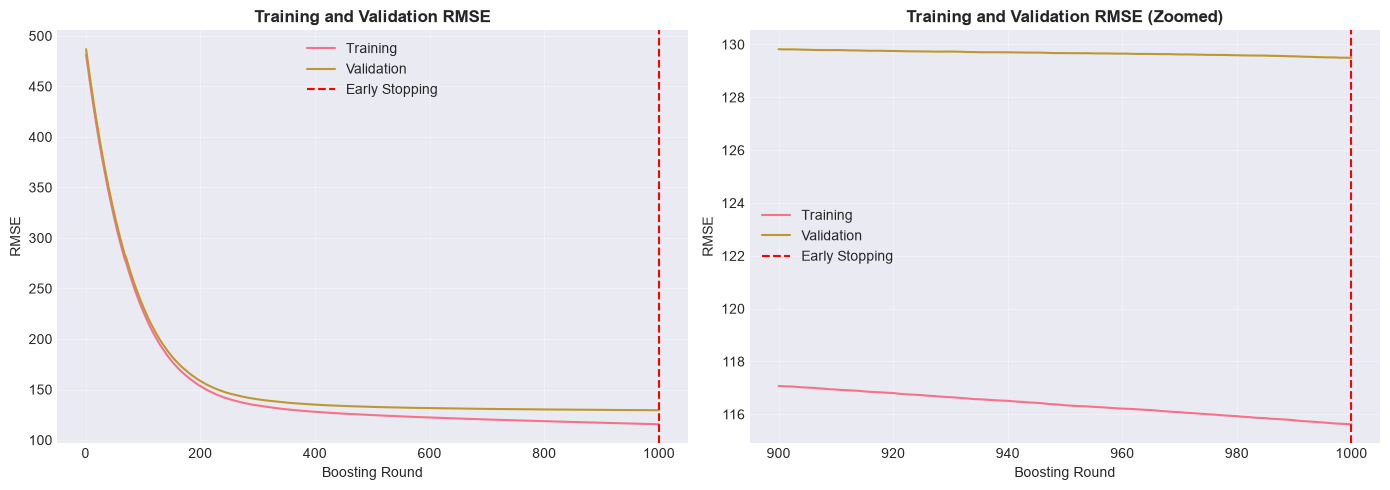

In [26]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation metric over time
evals_result = model_xgb.evals_result()
evals_result_train = evals_result['validation_0']
evals_result_val = evals_result['validation_1']

epochs = range(1, len(evals_result_train['rmse']) + 1)

# RMSE over epochs
axes[0].plot(epochs, evals_result_train['rmse'], label='Training', linewidth=1.5)
axes[0].plot(epochs, evals_result_val['rmse'], label='Validation', linewidth=1.5)
axes[0].axvline(x=model_xgb.best_iteration + 1, color='red', linestyle='--', label='Early Stopping')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Training and Validation RMSE', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom in on end
start_idx = max(0, model_xgb.best_iteration - 100)
axes[1].plot(epochs[start_idx:], evals_result_train['rmse'][start_idx:], label='Training', linewidth=1.5)
axes[1].plot(epochs[start_idx:], evals_result_val['rmse'][start_idx:], label='Validation', linewidth=1.5)
axes[1].axvline(x=model_xgb.best_iteration + 1, color='red', linestyle='--', label='Early Stopping')
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Training and Validation RMSE (Zoomed)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 8. Model Evaluation

### Metrics Explanation

We use multiple metrics because each tells a different story:

- **MAE (Mean Absolute Error)**: Average absolute error in MW. Easy to interpret (e.g., "off by 5 MW on average").
- **RMSE (Root Mean Squared Error)**: Penalizes large errors more heavily. Useful for finding models that avoid occasional huge mistakes.
- **R² (Coefficient of Determination)**: Proportion of variance explained (0-1). How much better than just using the mean?
- **WAPE (Weighted Absolute Percentage Error)**: Percentage error normalized by actual demand. Fairer for high vs low demand periods.
- **Bias (Mean Error)**: Average signed error. Positive = model tends to over-predict, negative = under-predict.

In [27]:
# Define evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    """
    Calculate all evaluation metrics for a model.
    
    Args:
        y_true: Actual values
        y_pred: Predicted values
        model_name: Name of the model (for printing)
    
    Returns:
        Dictionary with all metrics
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # WAPE: Weighted Absolute Percentage Error
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    
    # Bias: Mean error (positive = over-predict, negative = under-predict)
    bias = np.mean(y_pred - y_true)
    
    metrics = {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'WAPE': wape,
        'Bias': bias
    }
    
    return metrics

print("Evaluation function created.")

Evaluation function created.


In [28]:
# Make predictions on validation set
print("Making predictions...\n")

# XGBoost predictions
y_pred_xgb = model_xgb.predict(X_val)
print(f"XGBoost predictions: {y_pred_xgb.shape}")

# Baseline predictions (align with validation set)
print(f"Baseline 24hr predictions: {baseline_24hr.shape}")
print(f"Baseline 168hr predictions: {baseline_168hr.shape}")

Making predictions...

XGBoost predictions: (8784,)
Baseline 24hr predictions: (8760,)
Baseline 168hr predictions: (8616,)


In [29]:
# Evaluate all models
results = []

# Baseline 1: 24-hour
results.append(evaluate_model(y_val_aligned, baseline_24hr, 'Baseline (24hr lag)'))

# Baseline 2: 168-hour
results.append(evaluate_model(y_val_aligned_168, baseline_168hr, 'Baseline (168hr lag)'))

# XGBoost on full validation set
results.append(evaluate_model(y_val, y_pred_xgb, 'XGBoost'))

# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("MODEL COMPARISON - HELD-OUT TEST SET (2024, unseen during training)")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


MODEL COMPARISON - HELD-OUT TEST SET (2024, unseen during training)
               Model        MAE       RMSE       R²     WAPE       Bias
 Baseline (24hr lag) 177.103061 223.110762 0.788082 6.054736  -0.168207
Baseline (168hr lag) 143.422657 180.187822 0.861778 4.905365  -0.097625
             XGBoost 112.749826 141.227397 0.915103 3.854147 -59.659130


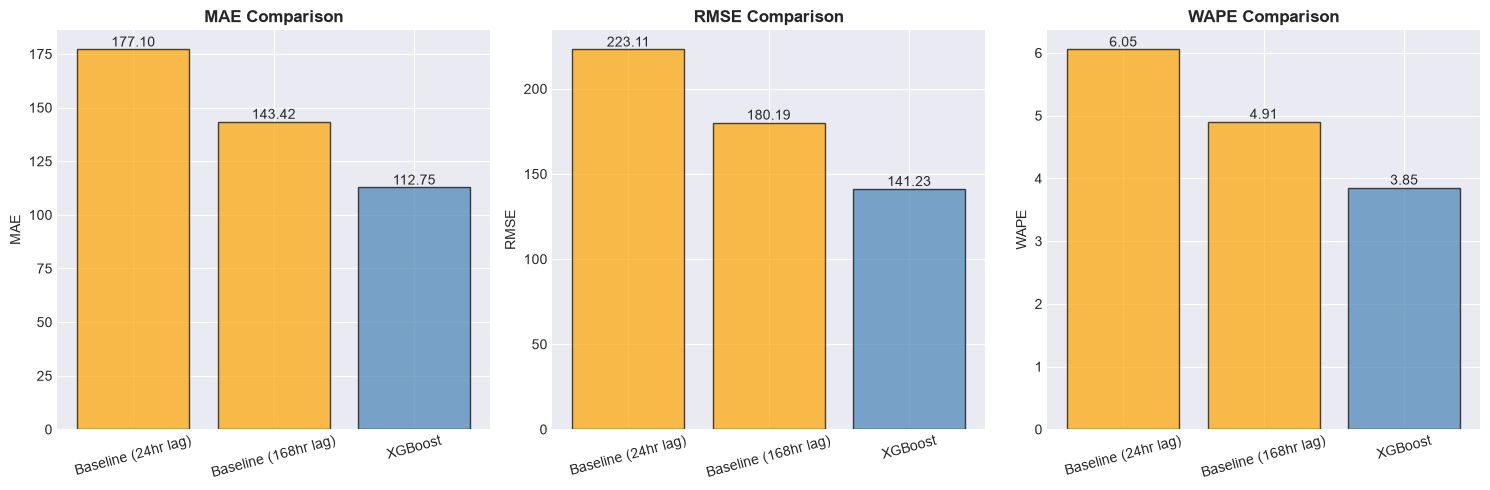


MODEL PERFORMANCE SUMMARY:

✓ XGBoost RMSE: 141.23 MW
  Baseline 24hr RMSE: 223.11 MW
  Baseline 168hr RMSE: 180.19 MW

→ XGBoost improves over 24-hour baseline by 36.7%


In [30]:
# Create visualization of metric comparison
metrics_to_plot = ['MAE', 'RMSE', 'WAPE']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, metric in enumerate(metrics_to_plot):
    model_names = results_df['Model'].values
    values = results_df[metric].values
    colors = ['orange', 'orange', 'steelblue']
    
    axes[idx].bar(model_names, values, color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{metric} Comparison', fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=15)
    
    # Add value labels on bars
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Summary
print("\nMODEL PERFORMANCE SUMMARY:")
print(f"\n✓ XGBoost RMSE: {results_df.loc[results_df['Model']=='XGBoost', 'RMSE'].values[0]:.2f} MW")
print(f"  Baseline 24hr RMSE: {results_df.loc[results_df['Model']=='Baseline (24hr lag)', 'RMSE'].values[0]:.2f} MW")
print(f"  Baseline 168hr RMSE: {results_df.loc[results_df['Model']=='Baseline (168hr lag)', 'RMSE'].values[0]:.2f} MW")

xgb_rmse = results_df.loc[results_df['Model']=='XGBoost', 'RMSE'].values[0]
baseline_24_rmse = results_df.loc[results_df['Model']=='Baseline (24hr lag)', 'RMSE'].values[0]

improvement = (baseline_24_rmse - xgb_rmse) / baseline_24_rmse * 100
print(f"\n→ XGBoost improves over 24-hour baseline by {improvement:.1f}%")

---

## 9. Error Analysis

### Where Does the Model Perform Best/Worst?

Understanding prediction errors by different dimensions helps identify model strengths and weaknesses.

In [31]:
# Create error analysis dataframe
error_analysis = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': y_pred_xgb,
    'Error': y_val.values - y_pred_xgb,
    'Abs_Error': np.abs(y_val.values - y_pred_xgb),
    'Pct_Error': np.abs(y_val.values - y_pred_xgb) / y_val.values * 100
}, index=y_val.index)

# Add time features for analysis
error_analysis['hour'] = error_analysis.index.hour
error_analysis['dayofweek'] = error_analysis.index.dayofweek
error_analysis['month'] = error_analysis.index.month
error_analysis['day_type'] = error_analysis['dayofweek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Categorize demand levels
demand_75 = error_analysis['Actual'].quantile(0.75)
demand_25 = error_analysis['Actual'].quantile(0.25)
error_analysis['demand_category'] = error_analysis['Actual'].apply(
    lambda x: 'Peak' if x > demand_75 else ('Normal' if x >= demand_25 else 'Low')
)

print("Error analysis prepared.")
print(error_analysis.head())

Error analysis prepared.
                      Actual    Predicted       Error   Abs_Error  Pct_Error  \
Timestamp                                                                      
2024-01-01 00:00:00  2636.84  2569.693115   67.146885   67.146885   2.546491   
2024-01-01 01:00:00  2701.49  2661.875000   39.615000   39.615000   1.466413   
2024-01-01 02:00:00  2846.70  2667.066406  179.633594  179.633594   6.310240   
2024-01-01 03:00:00  2940.80  2676.180420  264.619580  264.619580   8.998217   
2024-01-01 04:00:00  2601.37  2865.565918 -264.195918  264.195918  10.156030   

                     hour  dayofweek  month day_type demand_category  
Timestamp                                                             
2024-01-01 00:00:00     0          0      1  Weekday          Normal  
2024-01-01 01:00:00     1          0      1  Weekday          Normal  
2024-01-01 02:00:00     2          0      1  Weekday          Normal  
2024-01-01 03:00:00     3          0      1  Weekday       

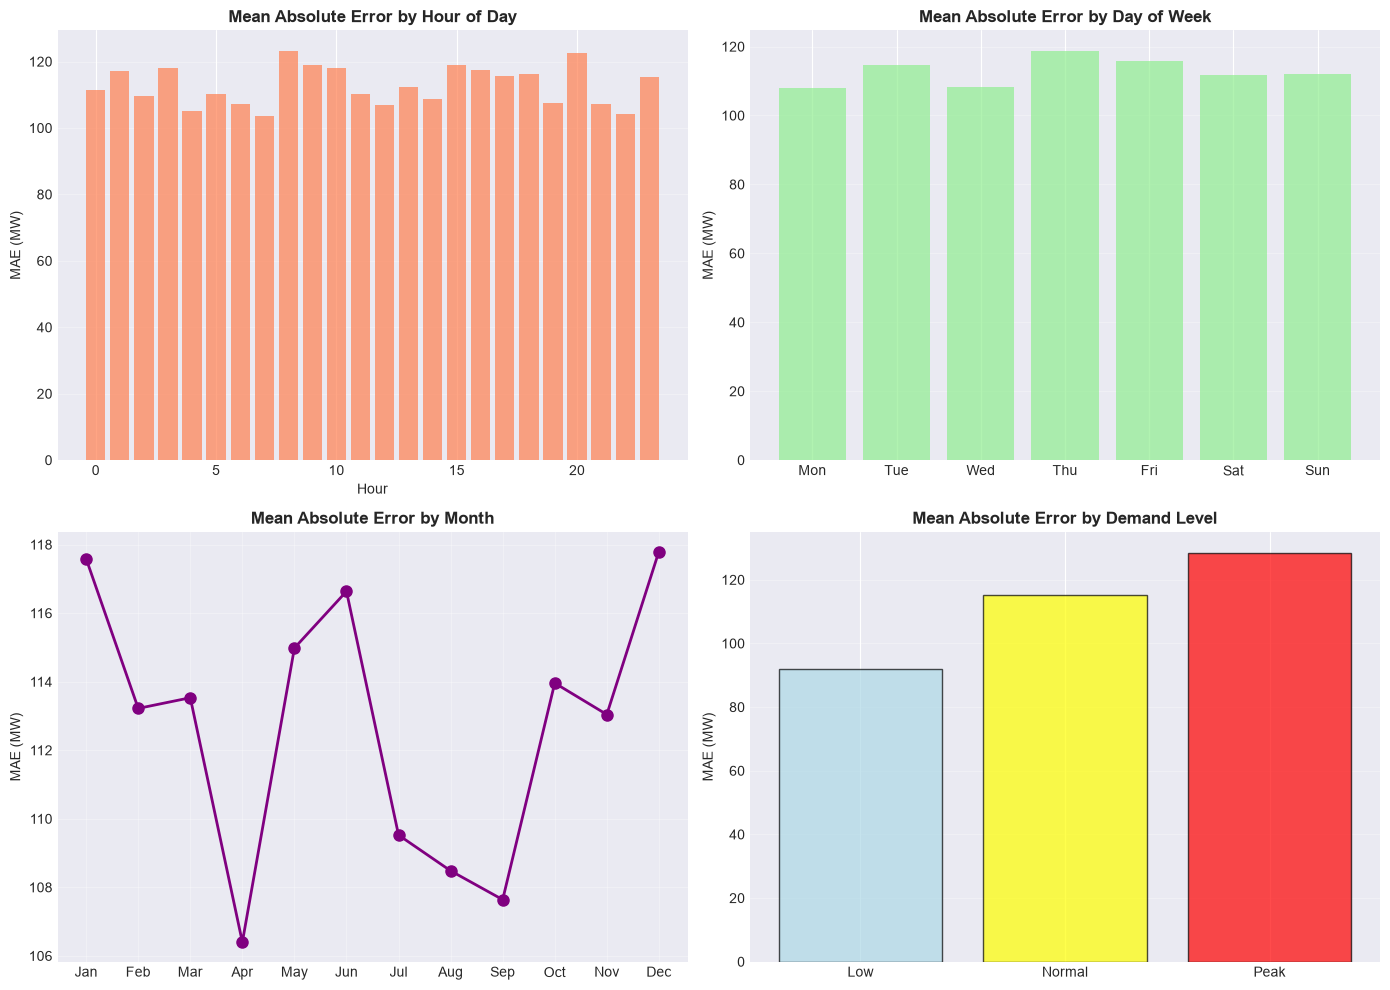


Error Analysis by Time Period:

Best performance (lowest MAE): Hour 7 (MAE: 103.51 MW)
Worst performance (highest MAE): Hour 8 (MAE: 123.19 MW)


In [32]:
# Error by hour of day
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MAE by hour
mae_by_hour = error_analysis.groupby('hour')['Abs_Error'].mean()
axes[0, 0].bar(mae_by_hour.index, mae_by_hour.values, color='coral', alpha=0.7)
axes[0, 0].set_title('Mean Absolute Error by Hour of Day', fontweight='bold')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('MAE (MW)')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Error by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
mae_by_day = error_analysis.groupby('dayofweek')['Abs_Error'].mean()
axes[0, 1].bar(mae_by_day.index, mae_by_day.values, color='lightgreen', alpha=0.7)
axes[0, 1].set_title('Mean Absolute Error by Day of Week', fontweight='bold')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_names)
axes[0, 1].set_ylabel('MAE (MW)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Error by month
mae_by_month = error_analysis.groupby('month')['Abs_Error'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 0].plot(mae_by_month.index, mae_by_month.values, marker='o', linewidth=2, markersize=8, color='purple')
axes[1, 0].set_title('Mean Absolute Error by Month', fontweight='bold')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names)
axes[1, 0].set_ylabel('MAE (MW)')
axes[1, 0].grid(True, alpha=0.3)

# Error by demand category
mae_by_demand = error_analysis.groupby('demand_category')['Abs_Error'].mean()
order = ['Low', 'Normal', 'Peak']
mae_by_demand = mae_by_demand.reindex(order)
axes[1, 1].bar(mae_by_demand.index, mae_by_demand.values, color=['lightblue', 'yellow', 'red'], alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Mean Absolute Error by Demand Level', fontweight='bold')
axes[1, 1].set_ylabel('MAE (MW)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nError Analysis by Time Period:")
print(f"\nBest performance (lowest MAE): Hour {mae_by_hour.idxmin()} (MAE: {mae_by_hour.min():.2f} MW)")
print(f"Worst performance (highest MAE): Hour {mae_by_hour.idxmax()} (MAE: {mae_by_hour.max():.2f} MW)")

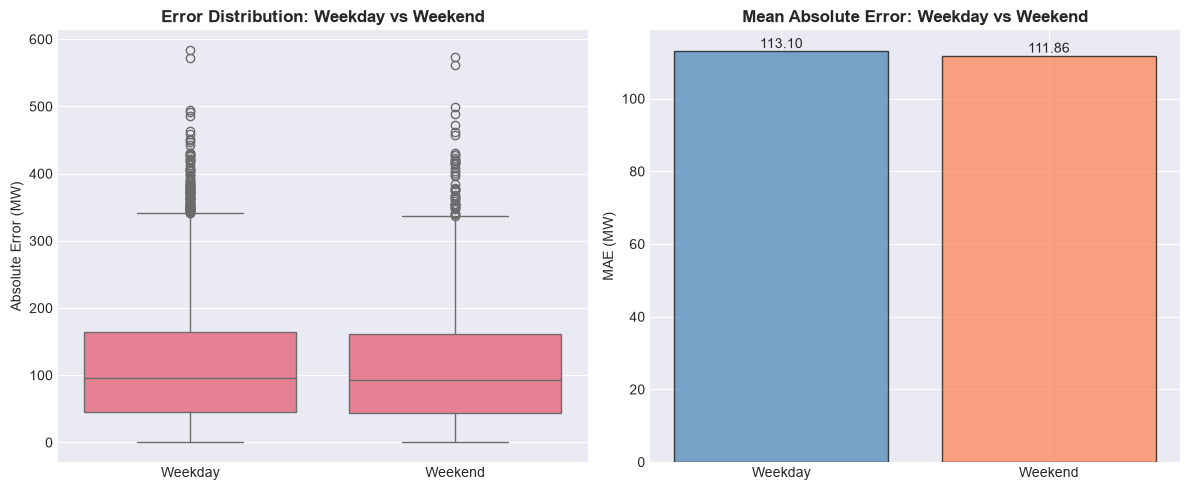

Weekday vs Weekend Performance:
  Weekday: MAE = 113.10 MW
  Weekend: MAE = 111.86 MW


In [33]:
# Weekday vs Weekend
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot of errors
error_analysis['day_type_name'] = error_analysis['day_type']
sns.boxplot(data=error_analysis, x='day_type_name', y='Abs_Error', ax=axes[0])
axes[0].set_title('Error Distribution: Weekday vs Weekend', fontweight='bold')
axes[0].set_ylabel('Absolute Error (MW)')
axes[0].set_xlabel('')

# Bar plot of MAE
mae_by_daytype = error_analysis.groupby('day_type')['Abs_Error'].mean()
axes[1].bar(mae_by_daytype.index, mae_by_daytype.values, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[1].set_title('Mean Absolute Error: Weekday vs Weekend', fontweight='bold')
axes[1].set_ylabel('MAE (MW)')
for i, v in enumerate(mae_by_daytype.values):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Weekday vs Weekend Performance:")
for day_type in ['Weekday', 'Weekend']:
    mae = error_analysis[error_analysis['day_type'] == day_type]['Abs_Error'].mean()
    print(f"  {day_type}: MAE = {mae:.2f} MW")

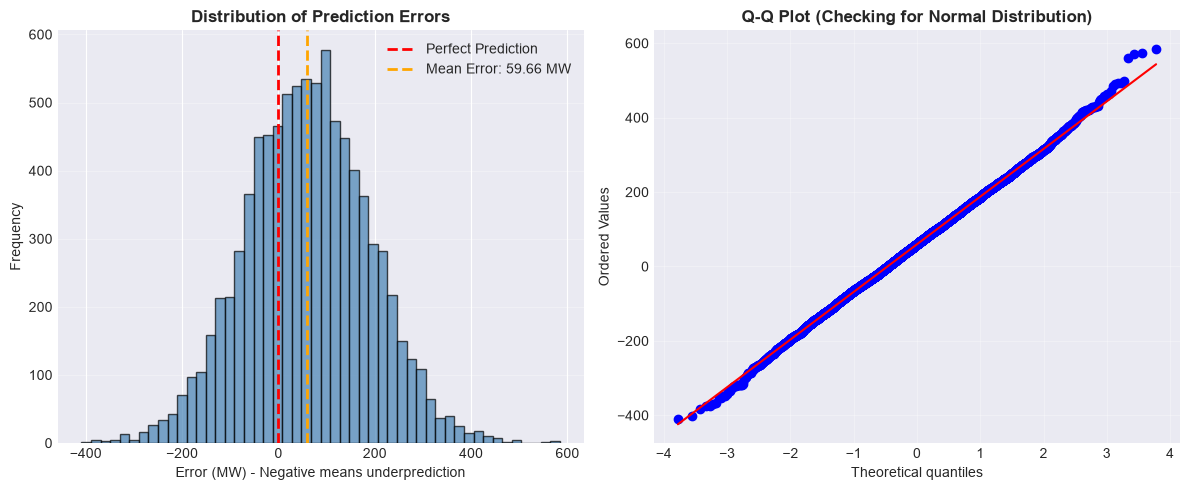

Error Statistics:
  Mean error (bias): 59.66 MW
  Std dev of errors: 128.01 MW
  Min error: -409.08 MW (worst underprediction)
  Max error: 583.83 MW (worst overprediction)


In [34]:
# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of errors
axes[0].hist(error_analysis['Error'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
axes[0].axvline(x=error_analysis['Error'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean Error: {error_analysis["Error"].mean():.2f} MW')
axes[0].set_title('Distribution of Prediction Errors', fontweight='bold')
axes[0].set_xlabel('Error (MW) - Negative means underprediction')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Q-Q plot for normality
from scipy import stats
stats.probplot(error_analysis['Error'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Checking for Normal Distribution)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error Statistics:")
print(f"  Mean error (bias): {error_analysis['Error'].mean():.2f} MW")
print(f"  Std dev of errors: {error_analysis['Error'].std():.2f} MW")
print(f"  Min error: {error_analysis['Error'].min():.2f} MW (worst underprediction)")
print(f"  Max error: {error_analysis['Error'].max():.2f} MW (worst overprediction)")

---

## 10. Actual vs Predicted Demand

### Visual Comparison Over Time

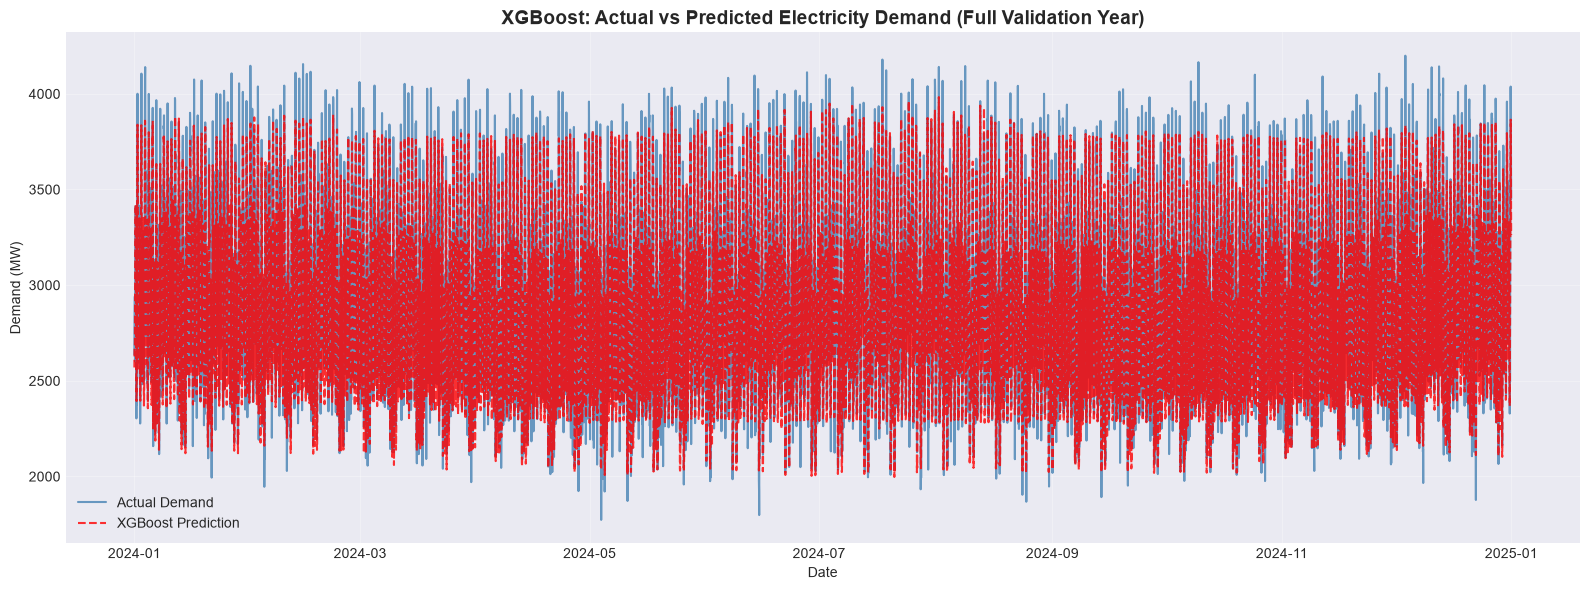

In [35]:
# Full validation period
plt.figure(figsize=(16, 6))
plt.plot(y_val.index, y_val.values, label='Actual Demand', color='steelblue', linewidth=1.5, alpha=0.8)
plt.plot(y_val.index, y_pred_xgb, label='XGBoost Prediction', color='red', linewidth=1.5, alpha=0.8, linestyle='--')
plt.title('XGBoost: Actual vs Predicted Electricity Demand (Full Validation Year)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

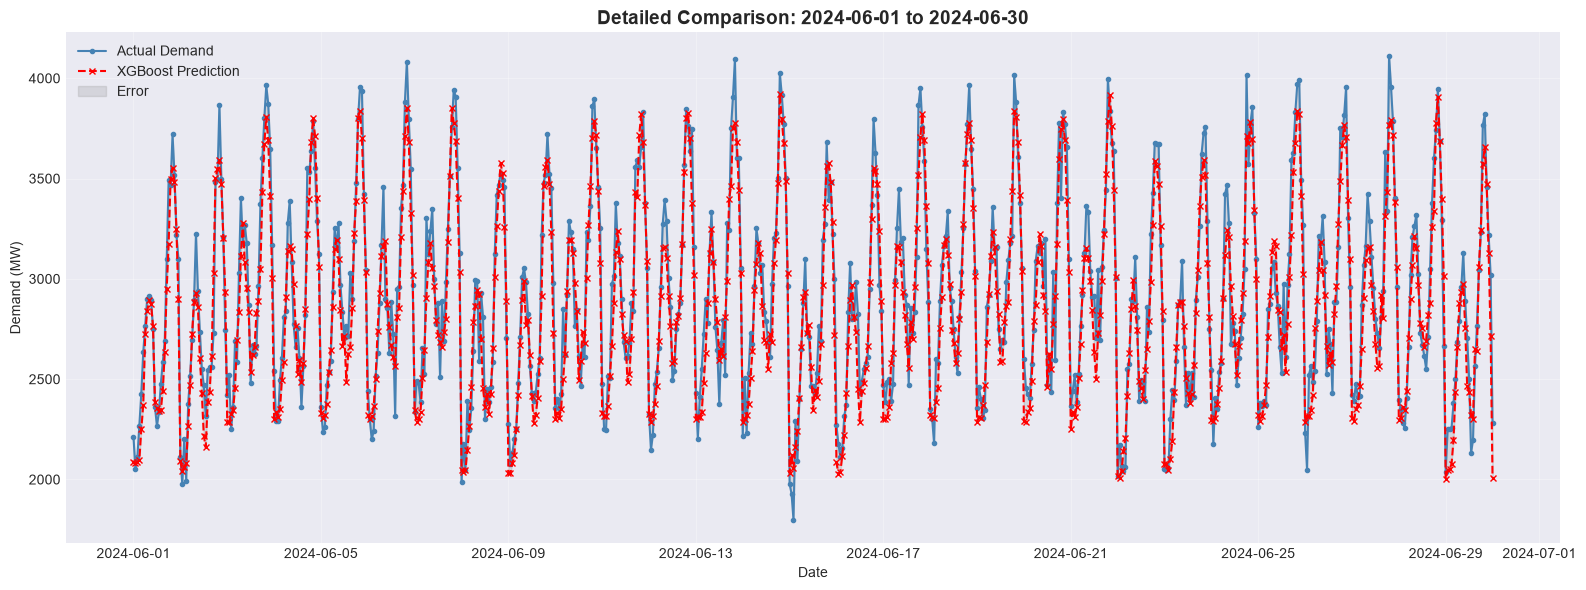

In [36]:
# Zoom in to a specific month for readability
start_date = '2024-06-01'
end_date = '2024-06-30'

mask = (y_val.index >= start_date) & (y_val.index <= end_date)
y_month = y_val[mask]
y_pred_month = y_pred_xgb[mask]

plt.figure(figsize=(16, 6))
plt.plot(y_month.index, y_month.values, label='Actual Demand', marker='o', color='steelblue', linewidth=1.5, markersize=3)
plt.plot(y_month.index, y_pred_month, label='XGBoost Prediction', marker='x', color='red', linewidth=1.5, markersize=5, linestyle='--')
plt.fill_between(y_month.index, y_month.values, y_pred_month, alpha=0.2, color='gray', label='Error')
plt.title(f'Detailed Comparison: {start_date} to {end_date}', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

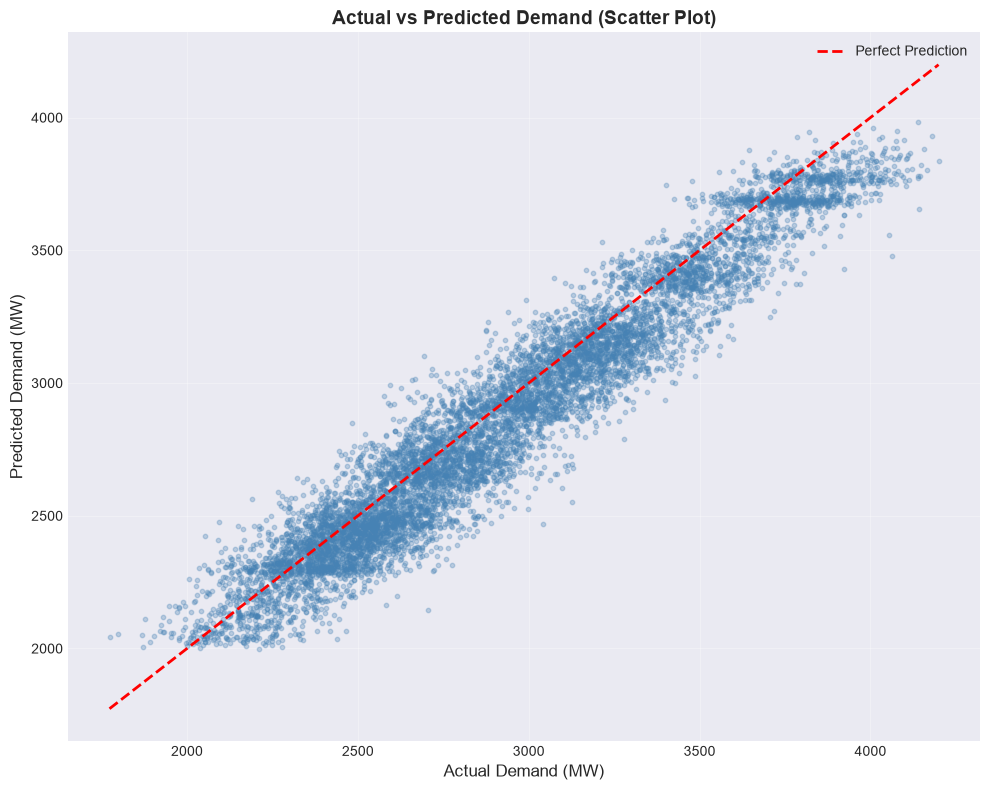

R² Score: 0.9151
This means the model explains 91.51% of the variance in demand.


In [37]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_val, y_pred_xgb, alpha=0.3, s=10, color='steelblue')

# Perfect prediction line
min_val = min(y_val.min(), y_pred_xgb.min())
max_val = max(y_val.max(), y_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Demand (MW)', fontsize=12)
plt.ylabel('Predicted Demand (MW)', fontsize=12)
plt.title('Actual vs Predicted Demand (Scatter Plot)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

r_squared = r2_score(y_val, y_pred_xgb)
print(f"R² Score: {r_squared:.4f}")
print(f"This means the model explains {r_squared*100:.2f}% of the variance in demand.")

---

## 11. Feature Importance

### Which Features Does the Model Use Most?

In [38]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (XGBoost):")
print(feature_importance.to_string(index=False))

# Calculate cumulative importance
feature_importance['Cumulative'] = feature_importance['Importance'].cumsum()
feature_importance['Cumulative_Pct'] = feature_importance['Cumulative'] / feature_importance['Importance'].sum() * 100

Feature Importance (XGBoost):
                 Feature  Importance
        demand_lag_168hr    0.661533
         Demand_lag_24hr    0.130979
                    hour    0.065048
              is_weekend    0.059055
               dayofweek    0.036491
             Temperature    0.013185
                    year    0.008240
demand_rolling_mean_24hr    0.006299
 demand_rolling_std_24hr    0.004276
                Humidity    0.003910
               dayofyear    0.003208
              weekofyear    0.002911
              is_holiday    0.001955
                   month    0.001512
                 quarter    0.001398


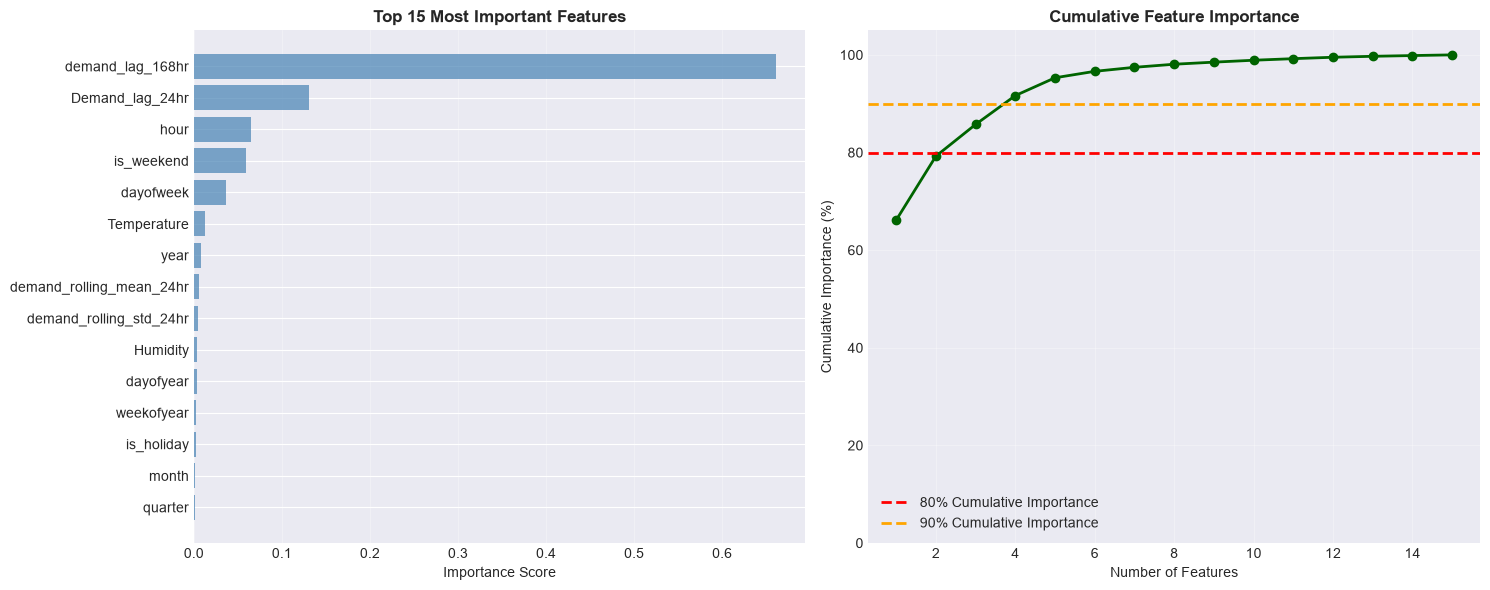


Feature Efficiency:
  80% of importance: First 3 features
  90% of importance: First 4 features
  Total features: 15


In [39]:
# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot of top features
top_n = 15
top_features = feature_importance.head(top_n)

axes[0].barh(range(len(top_features)), top_features['Importance'].values, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['Feature'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance Score')
axes[0].set_title(f'Top {top_n} Most Important Features', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Cumulative importance
axes[1].plot(range(1, len(feature_importance)+1), feature_importance['Cumulative_Pct'].values, 
            marker='o', linewidth=2, markersize=6, color='darkgreen')
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% Cumulative Importance')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% Cumulative Importance')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

# Find how many features needed for 80% and 90%
n_features_80 = (feature_importance['Cumulative_Pct'] <= 80).sum() + 1
n_features_90 = (feature_importance['Cumulative_Pct'] <= 90).sum() + 1

print(f"\nFeature Efficiency:")
print(f"  80% of importance: First {n_features_80} features")
print(f"  90% of importance: First {n_features_90} features")
print(f"  Total features: {len(feature_importance)}")

### Interpretation of Feature Importance

The most important features make sense for electricity demand forecasting:

- **Lag features (24hr, 168hr)**: High importance because demand patterns repeat daily and weekly
- **Hour of day**: Critical because demand varies dramatically by hour
- **Temperature**: Drives HVAC loads (heating/cooling)
- **Rolling mean/std**: Captures recent demand trends

If the top features were random noise instead of these interpretable patterns, we'd suspect the model is overfitting or the data has issues.

---

## 12. Save the Model

In [40]:
# Create models directory if it doesn't exist
import os

models_dir = 'models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Created directory: {models_dir}")

# Prepare model package
model_package = {
    'model': model_xgb,
    'features': list(X_train.columns),
    'feature_importance': dict(zip(feature_importance['Feature'], feature_importance['Importance'])),
    'metrics': {
        'MAE': results_df.loc[results_df['Model']=='XGBoost', 'MAE'].values[0],
        'RMSE': results_df.loc[results_df['Model']=='XGBoost', 'RMSE'].values[0],
        'R2': results_df.loc[results_df['Model']=='XGBoost', 'R\u00b2'].values[0],
        'WAPE': results_df.loc[results_df['Model']=='XGBoost', 'WAPE'].values[0],
        'Bias': results_df.loc[results_df['Model']=='XGBoost', 'Bias'].values[0]
    },
    'training_date': pd.Timestamp.now().isoformat(),
    'training_period': {
        'start': str(X_train.index.min()),
        'end': str(X_train.index.max())
    },
    'early_stopping_period': {
        'start': str(X_earlystop.index.min()),
        'end': str(X_earlystop.index.max())
    },
    'test_period': {
        'start': str(X_val.index.min()),
        'end': str(X_val.index.max()),
        'note': 'Held-out test set. Never used in training or early stopping -- metrics above are a genuine out-of-sample evaluation.'
    }
}

print("Model package created.")
print(f"Package contents: {list(model_package.keys())}")


Model package created.
Package contents: ['model', 'features', 'feature_importance', 'metrics', 'training_date', 'training_period', 'early_stopping_period', 'test_period']


In [41]:
# Save the model package
model_path = os.path.join(models_dir, 'electricity_xgb_prediction_model.pkl')

joblib.dump(model_package, model_path)

print(f"✓ Model saved to: {model_path}")
print(f"✓ File size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

✓ Model saved to: models\electricity_xgb_prediction_model.pkl
✓ File size: 4.56 MB


In [42]:
# Verify the saved model can be loaded
print("\nVerifying saved model...\n")

loaded_package = joblib.load(model_path)

print("✓ Model loaded successfully")
print(f"✓ Features in saved model: {loaded_package['features']}")
print(f"✓ Saved metrics: {loaded_package['metrics']}")

# Quick test: make a prediction with loaded model
test_prediction = loaded_package['model'].predict(X_val.iloc[:5])
print(f"✓ Sample predictions from loaded model: {test_prediction}")


Verifying saved model...

✓ Model loaded successfully
✓ Features in saved model: ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'quarter', 'weekofyear', 'Temperature', 'Humidity', 'is_holiday', 'is_weekend', 'Demand_lag_24hr', 'demand_lag_168hr', 'demand_rolling_mean_24hr', 'demand_rolling_std_24hr']
✓ Saved metrics: {'MAE': np.float64(112.74982648524069), 'RMSE': np.float64(141.22739694845924), 'R2': np.float64(0.9151026056190288), 'WAPE': np.float64(3.8541467058599648), 'Bias': np.float64(-59.659129589754805)}
✓ Sample predictions from loaded model: [2569.693  2661.875  2667.0664 2676.1804 2865.566 ]


---

## 13. Summary and Key Findings

In [43]:
# Final summary
print("="*80)
print("ELECTRICITY DEMAND FORECASTING - FINAL RESULTS")
print("="*80)

print(f"\n📊 DATASET INFORMATION:")
print(f"  Total observations: {len(data)}")
print(f"  Date range: {data.index.min()} to {data.index.max()}")
print(f"  Features used: {len(X_train.columns)}")

print(f"\n📈 TRAINING DETAILS:")
print(f"  Training set size: {len(X_train)} observations ({X_train.index.min()} to {X_train.index.max()})")
print(f"  Validation set size: {len(X_val)} observations ({X_val.index.min()} to {X_val.index.max()})")
print(f"  XGBoost trees trained: {model_xgb.best_iteration + 1} / {model_xgb.n_estimators}")
print(f"  Early stopping after {model_xgb.early_stopping_rounds} rounds without improvement")

print(f"\n🎯 MODEL PERFORMANCE (XGBoost):")
xgb_metrics = results_df[results_df['Model']=='XGBoost'].iloc[0]
print(f"  MAE:  {xgb_metrics['MAE']:.2f} MW")
print(f"  RMSE: {xgb_metrics['RMSE']:.2f} MW")
print(f"  R²:   {xgb_metrics['R²']:.4f}")
print(f"  WAPE: {xgb_metrics['WAPE']:.2f}%")
print(f"  Bias: {xgb_metrics['Bias']:+.2f} MW")

print(f"\n📊 BASELINE COMPARISON:")
baseline_24_metrics = results_df[results_df['Model']=='Baseline (24hr lag)'].iloc[0]
improvement_pct = (baseline_24_metrics['RMSE'] - xgb_metrics['RMSE']) / baseline_24_metrics['RMSE'] * 100
print(f"  Baseline (24hr):  RMSE = {baseline_24_metrics['RMSE']:.2f} MW")
print(f"  XGBoost:          RMSE = {xgb_metrics['RMSE']:.2f} MW")
print(f"  ✓ Improvement:    {improvement_pct:+.1f}%")

print(f"\n⭐ TOP 5 FEATURES:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"  {idx+1}. {row['Feature']:25s} (importance: {row['Importance']:.4f})")

print(f"\n✅ IMPORTANT NOTES:")
print(f"  • This dataset is SYNTHETIC (simulated)")
print(f"  • Target leakage has been eliminated (rolling features use only past data)")
print(f"  • Train/validation split is chronological (no future data leakage)")
print(f"  • Model saved to: models/electricity_xgb_prediction_model.pkl")
print(f"  • Next step: Deploy Streamlit dashboard for interactive exploration")

print("="*80)

ELECTRICITY DEMAND FORECASTING - FINAL RESULTS

📊 DATASET INFORMATION:
  Total observations: 43676
  Date range: 2020-01-08 00:00:00 to 2024-12-31 23:00:00
  Features used: 15

📈 TRAINING DETAILS:
  Training set size: 26132 observations (2020-01-08 00:00:00 to 2022-12-31 23:00:00)
  Validation set size: 8784 observations (2024-01-01 00:00:00 to 2024-12-31 23:00:00)
  XGBoost trees trained: 1000 / 1000
  Early stopping after 50 rounds without improvement

🎯 MODEL PERFORMANCE (XGBoost):
  MAE:  112.75 MW
  RMSE: 141.23 MW
  R²:   0.9151
  WAPE: 3.85%
  Bias: -59.66 MW

📊 BASELINE COMPARISON:
  Baseline (24hr):  RMSE = 223.11 MW
  XGBoost:          RMSE = 141.23 MW
  ✓ Improvement:    +36.7%

⭐ TOP 5 FEATURES:
  13. demand_lag_168hr          (importance: 0.6615)
  12. Demand_lag_24hr           (importance: 0.1310)
  1. hour                      (importance: 0.0650)
  11. is_weekend                (importance: 0.0591)
  2. dayofweek                 (importance: 0.0365)

✅ IMPORTANT NOTES:


---

## 14. Forecasting Beyond Available Data (Next Year)

### Why this is harder than the validation-set predictions above

Everything so far predicts a single hour where we already *know* the lag features
(demand 24h/168h ago) and the weather. To forecast **new future hours** (e.g. 2025)
we don't have either of those, so this section makes two explicit assumptions:

1. **Recursive (multi-step) forecasting** — to predict hour *t*, we need demand at
   *t-24* and *t-168*. For the first 168 hours of the forecast those exist in real
   history; beyond that we feed the model's *own previous predictions* back in as
   the lag features. Errors can compound the further out you go — this is expected
   and should be stated as a limitation, not hidden.
2. **Weather proxy** — we have no real future Temperature/Humidity forecast, so we
   use the historical average for the same month/day/hour (a "seasonal naive"
   weather assumption) as a stand-in. Real deployment would plug in an actual
   weather forecast API here instead.

**This is a demonstration of the mechanism, not a claim that year-ahead hourly
electricity forecasts are reliable — accuracy degrades substantially beyond the
first few days.**


In [44]:
# Reindex to a gap-free hourly series (the raw data actually has a few missing hours,
# not just the fully-empty rows removed earlier) so that lag/rolling offsets by
# array position are guaranteed to correspond to real 24h / 168h gaps.
full_index = pd.date_range(data.index.min(), data.index.max(), freq='h')
history = data.reindex(full_index)
history['Demand'] = history['Demand'].interpolate(method='time')
history['Temperature'] = history['Temperature'].interpolate(method='time')
history['Humidity'] = history['Humidity'].interpolate(method='time')

print(f"Gap-free history: {len(history)} hourly rows, {history.isna().sum().sum()} remaining NaNs in core columns")


Gap-free history: 43680 hourly rows, 52 remaining NaNs in core columns


In [45]:
def weather_proxy(ts, hist):
    """Seasonal-naive stand-in for a real weather forecast: average
    Temperature/Humidity historically observed at this month/day/hour."""
    same_slot = hist[(hist.index.month == ts.month) &
                      (hist.index.day == ts.day) &
                      (hist.index.hour == ts.hour)]
    if len(same_slot) == 0:
        same_slot = hist[(hist.index.month == ts.month) & (hist.index.hour == ts.hour)]
    return same_slot['Temperature'].mean(), same_slot['Humidity'].mean()


In [46]:
def forecast_future(model, feature_cols, history, periods=8760):
    """Recursively forecast `periods` hours beyond the end of `history`.

    Args:
        model: trained XGBRegressor
        feature_cols: exact feature order the model expects (X_train.columns)
        history: gap-free hourly DataFrame with a 'Demand' column
        periods: number of future hours to forecast (8760 = 1 year)
    Returns:
        DataFrame indexed by future timestamp with a 'Demand_forecast' column
    """
    last_ts = history.index.max()
    future_index = pd.date_range(start=last_ts + pd.Timedelta(hours=1), periods=periods, freq='h')

    morocco_holidays = holidays.Morocco(years=range(last_ts.year, future_index.max().year + 1))

    # Combined demand array: real history followed by predictions as they're made.
    # Using array positions (not .loc on a growing Series) keeps this fast and,
    # since `history` is gap-free hourly, position offsets of 24 / 168 are exact.
    n_hist = len(history)
    combined_demand = np.concatenate([history['Demand'].values, np.zeros(periods)])

    predictions = []
    for i, ts in enumerate(future_index):
        idx = n_hist + i
        temp, hum = weather_proxy(ts, history)

        row = {
            'hour': ts.hour,
            'dayofweek': ts.dayofweek,
            'month': ts.month,
            'year': ts.year,
            'dayofyear': ts.dayofyear,
            'quarter': ts.quarter,
            'weekofyear': int(ts.isocalendar()[1]),
            'Temperature': temp,
            'Humidity': hum,
            'is_holiday': int(ts.date() in morocco_holidays),
            'is_weekend': int(ts.dayofweek in [5, 6]),
            'Demand_lag_24hr': combined_demand[idx - 24],
            'demand_lag_168hr': combined_demand[idx - 168],
            'demand_rolling_mean_24hr': combined_demand[idx - 24:idx].mean(),
            'demand_rolling_std_24hr': combined_demand[idx - 24:idx].std(),
        }

        X_row = pd.DataFrame([row])[feature_cols]
        pred = model.predict(X_row)[0]
        combined_demand[idx] = pred
        predictions.append(pred)

    return pd.DataFrame({'Demand_forecast': predictions}, index=future_index)

print("forecast_future() defined.")


forecast_future() defined.


In [47]:
# Forecast the year following the dataset (recursive, ~8760 hourly steps).
# This loop makes one model.predict() call per hour, so it takes a little while.
future_forecast = forecast_future(model_xgb, list(X_train.columns), history, periods=8760)

print(f"Forecast generated: {future_forecast.index.min()} to {future_forecast.index.max()}")
print(future_forecast.head())
print(future_forecast.describe())


Forecast generated: 2025-01-01 00:00:00 to 2025-12-31 23:00:00
                     Demand_forecast
2025-01-01 00:00:00      2575.208008
2025-01-01 01:00:00      2591.400391
2025-01-01 02:00:00      2631.348389
2025-01-01 03:00:00      2708.131104
2025-01-01 04:00:00      2801.765625
       Demand_forecast
count      8760.000000
mean       2839.827393
std         470.712189
min        2003.860229
25%        2441.694885
50%        2758.611206
75%        3157.192017
max        3925.314941


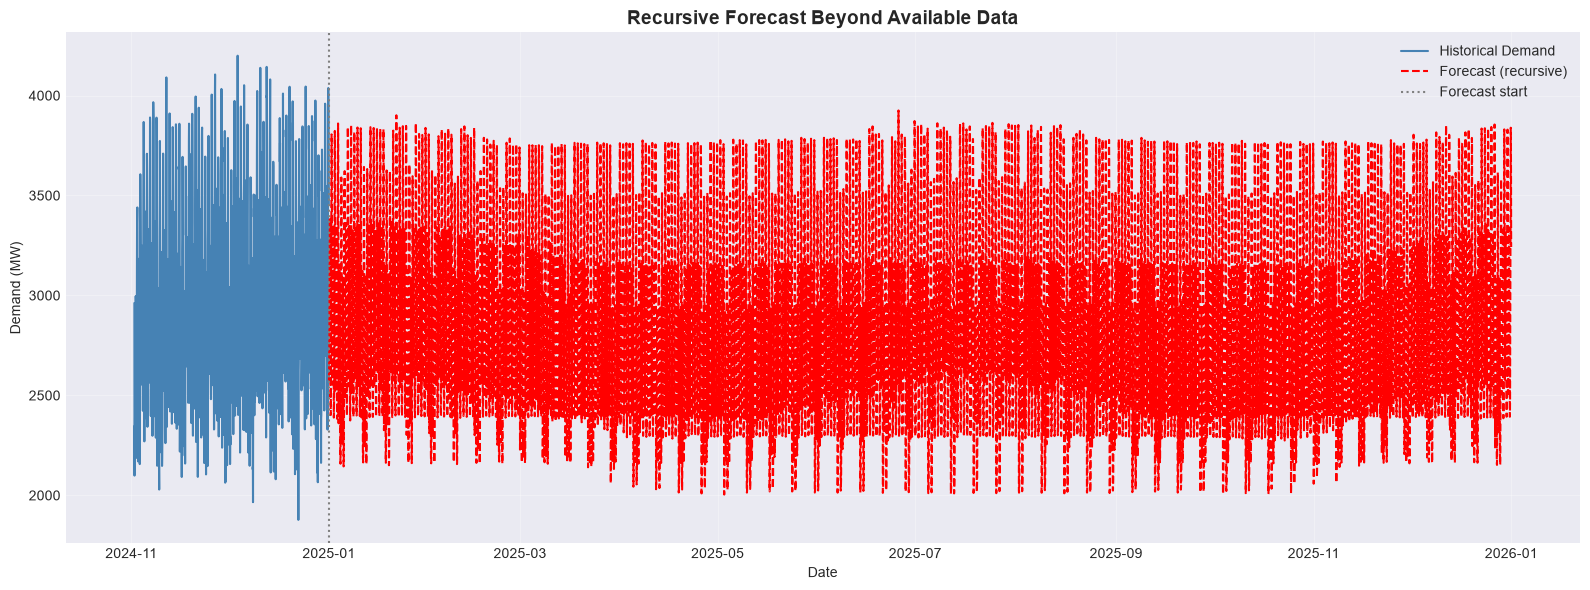


Reminder: confidence in this forecast should be treated as decreasing with
horizon — the first few days use mostly real lag data, later months rely
increasingly on the model's own prior predictions and proxy weather.


In [48]:
# Plot the tail of real history alongside the new forecast
fig, ax = plt.subplots(figsize=(16, 6))

recent_history = history['Demand'][history.index >= history.index.max() - pd.Timedelta(days=60)]
ax.plot(recent_history.index, recent_history.values, label='Historical Demand', color='steelblue')
ax.plot(future_forecast.index, future_forecast['Demand_forecast'], label='Forecast (recursive)',
        color='red', linestyle='--')
ax.axvline(history.index.max(), color='gray', linestyle=':', label='Forecast start')

ax.set_title('Recursive Forecast Beyond Available Data', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nReminder: confidence in this forecast should be treated as decreasing with")
print("horizon — the first few days use mostly real lag data, later months rely")
print("increasingly on the model's own prior predictions and proxy weather.")


---

## Notebook Complete ✅

### What We've Accomplished:

1. ✅ **Data Loading & Cleaning**: Handled missing values appropriately
2. ✅ **Feature Engineering**: Created 15+ features without target leakage
3. ✅ **Holiday Feature**: Implemented Moroccan holiday detection
4. ✅ **Proper Data Splitting**: Chronological train/validation with no future leakage
5. ✅ **Baseline Models**: Created naive forecasts for comparison
6. ✅ **XGBoost Training**: Trained with proper validation set for early stopping
7. ✅ **Comprehensive Evaluation**: Multiple metrics (MAE, RMSE, R², WAPE, Bias)
8. ✅ **Error Analysis**: Identified model performance by hour, day, month, demand level
9. ✅ **Visualizations**: Created 10+ informative charts
10. ✅ **Feature Importance**: Analyzed which features drive predictions
11. ✅ **Model Saving**: Packaged and saved for future use
12. ✅ **Documentation**: Clear explanations throughout

### Next Steps:

- Run the Streamlit dashboard: `streamlit run dashboard.py`
- Review model performance in interactive charts
- Make real-time predictions with the saved model